In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
#Load csv file
data = pd.read_csv('historic_dataset1.csv')
print(data.head())


# Define the categories
expense_categories = ["Utilities", "Groceries", "Food", "Transportation", "Stationary",
                      "Subscriptions", "Entertainment", "Medical_Expenses", "Phone/Internet_Bill"]

   Month  Utilities  Groceries  Food  Transportation  Stationary  \
0      1       3500       4200  5200            1800         500   
1      2       3600       4100  5400            1900         550   
2      3       3700       4300  5600            2000         600   
3      4       3800       4400  5800            2100         620   
4      5       3900       4500  6000            2200         650   

   Subscriptions  Entertainment  Medical_Expenses  Phone/Internet_Bill  \
0           1200           2400              1500                  900   
1           1300           2500              1600                  920   
2           1400           2600              1700                  950   
3           1450           2700              1800                  980   
4           1500           2800              1850                 1000   

   Total_Expenses  
0           21200  
1           21870  
2           22850  
3           23650  
4           24400  



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


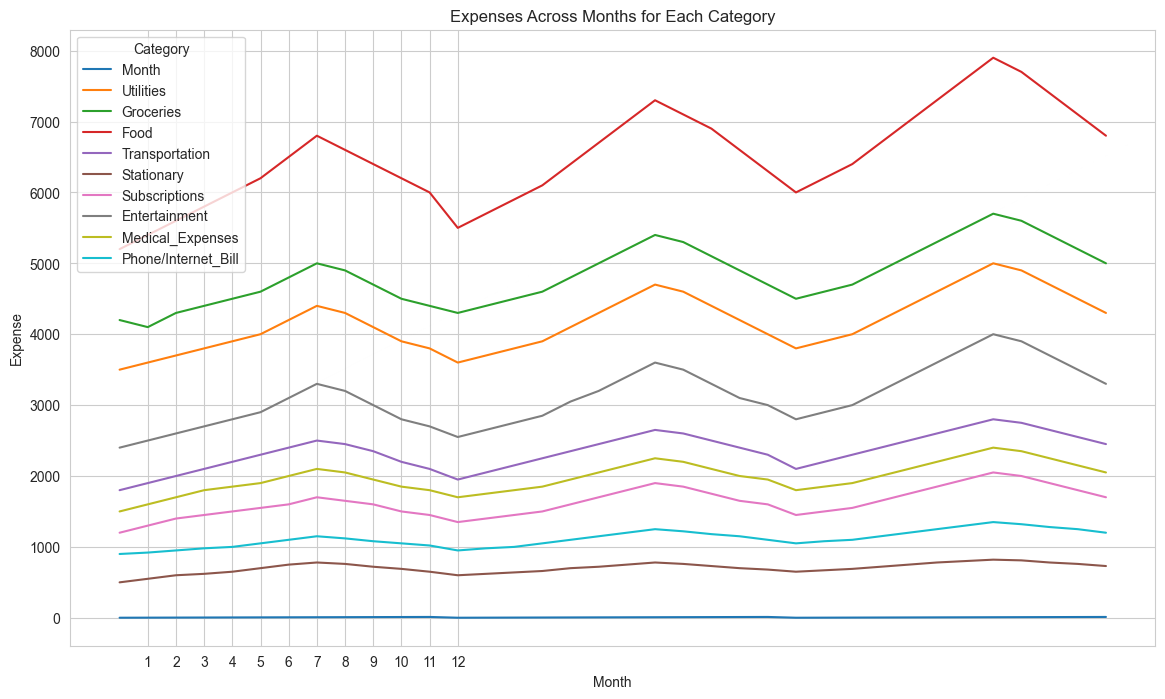

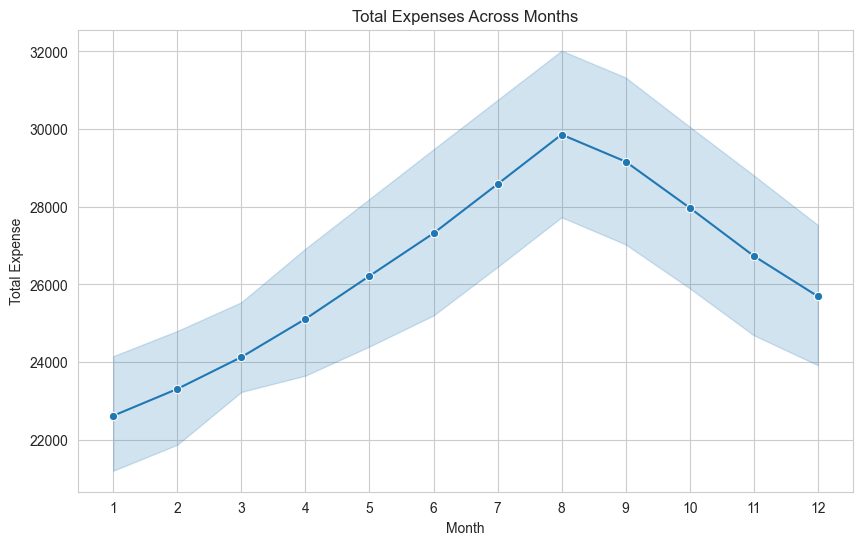

In [3]:
%pip install matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Set the style of seaborn
sns.set_style("whitegrid")

# Plot expenses across months for each category
plt.figure(figsize=(14, 8))
sns.lineplot(data=data.drop(columns=['Total_Expenses']), dashes=False)
plt.title('Expenses Across Months for Each Category')
plt.xlabel('Month')
plt.ylabel('Expense')
plt.legend(title='Category')
plt.xticks(range(1, 13))
plt.show()

# Plot total expenses across months
plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x='Month', y='Total_Expenses', marker='o')
plt.title('Total Expenses Across Months')
plt.xlabel('Month')
plt.ylabel('Total Expense')
plt.xticks(range(1, 13))
plt.show()


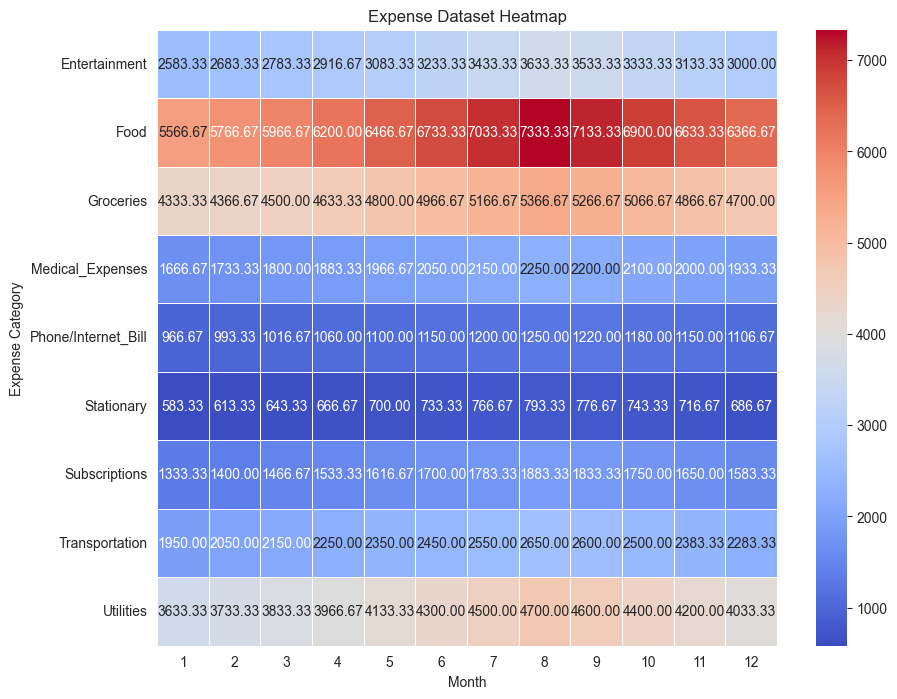

In [4]:
import seaborn as sns

# Pivot the dataset
pivot_data = data.pivot_table(index=None, columns='Month', values=expense_categories)

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Expense Dataset Heatmap')
plt.xlabel('Month')
plt.ylabel('Expense Category')
plt.yticks(rotation=0)  # Rotate y-axis labels for better readability
plt.show()


In [5]:
# Required imports
import pandas as pd
import numpy as np
from math import sqrt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load your dataset
data = pd.read_csv('historic_dataset1.csv')  # Make sure the path matches your file

# Automatically detect expense categories (all columns except 'Month')
expense_categories = [col for col in data.columns if col != 'Month']

# Function to train Random Forest regression model for a given expense category
def train_random_forest_model(category):
    X = data['Month'].values.reshape(-1, 1)
    y = data[category].values
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    y_pred = model.predict(X)
    rmse = sqrt(mean_squared_error(y, y_pred))  # Correct RMSE calculation for older sklearn
    return model, rmse

# Train Random Forest models for each expense category
random_forest_models = {}
for category in expense_categories:
    model, rmse = train_random_forest_model(category)
    random_forest_models[category] = {'model': model, 'rmse': rmse}

# Print the root mean squared error (RMSE) for each category
print("Random Forest Regression RMSE values:")
for category, info in random_forest_models.items():
    print(f"{category}: RMSE = {info['rmse']:.2f}")

# Initialize predicted_expenses dictionary
predicted_expenses = {}

# Function to predict expenses for each category for a given month and sum them up using Random Forest models
def predict_expenses_with_random_forest(month):
    total_expense = 0
    for category, info in random_forest_models.items():
        model = info['model']
        predicted_expense = model.predict(np.array([[month]]))[0]
        predicted_expense = round(predicted_expense, 2)
        predicted_expenses[category] = predicted_expense
        total_expense += predicted_expense
        print(f"{category}: ${predicted_expense:.2f}")
    print(f"Total Expense for Month {month}: ${total_expense:.2f}")
    return predicted_expenses

# ---- Example usage ----
# To predict for August (month=8), run:
# results = predict_expenses_with_random_forest(8)


Random Forest Regression RMSE values:
Utilities: RMSE = 208.83
Groceries: RMSE = 249.15
Food: RMSE = 394.53
Transportation: RMSE = 126.71
Stationary: RMSE = 37.12
Subscriptions: RMSE = 114.41
Entertainment: RMSE = 249.00
Medical_Expenses: RMSE = 112.59
Phone/Internet_Bill: RMSE = 76.13
Total_Expenses: RMSE = 1547.35


In [6]:
for category, expense in predicted_expenses.items():
    predicted_expenses[category] = round(expense, 2)
    
print(predicted_expenses)

{}


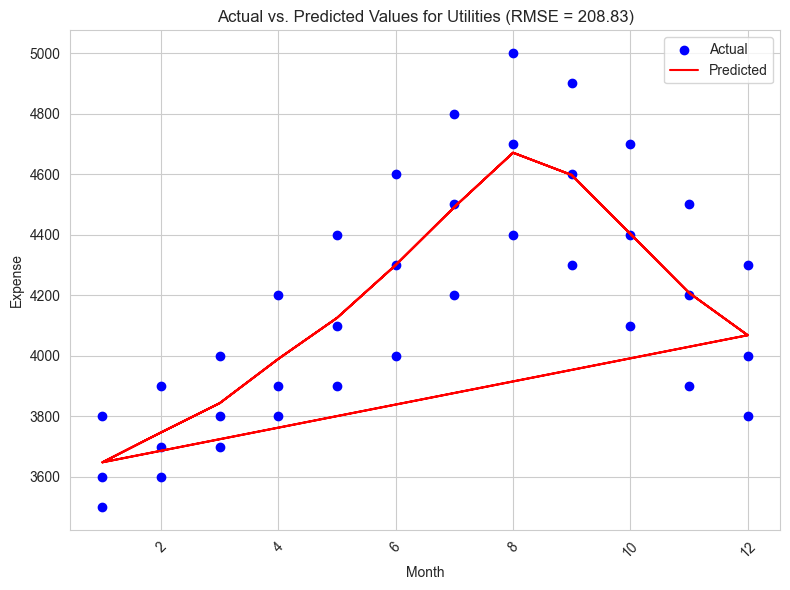

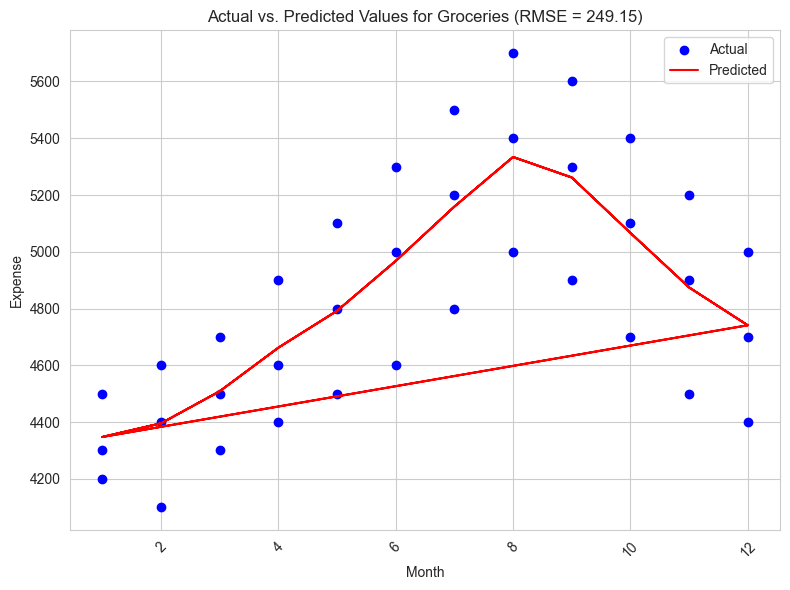

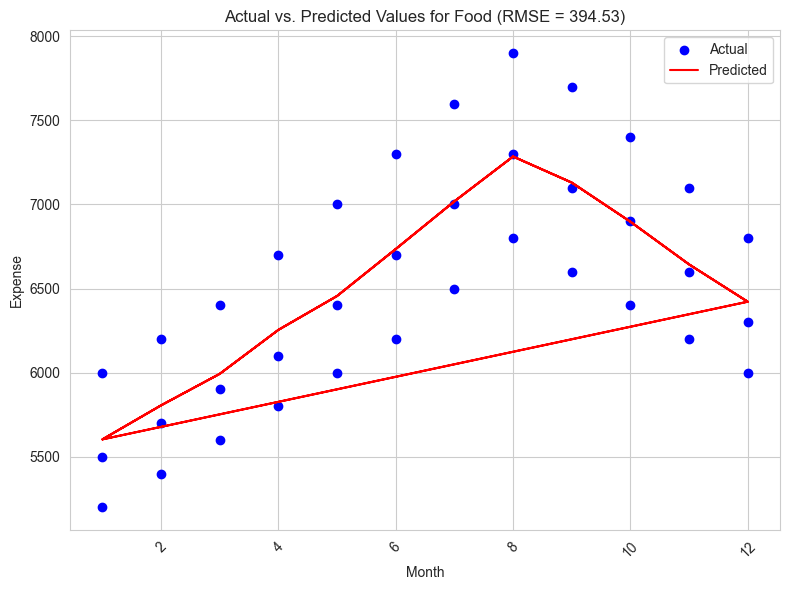

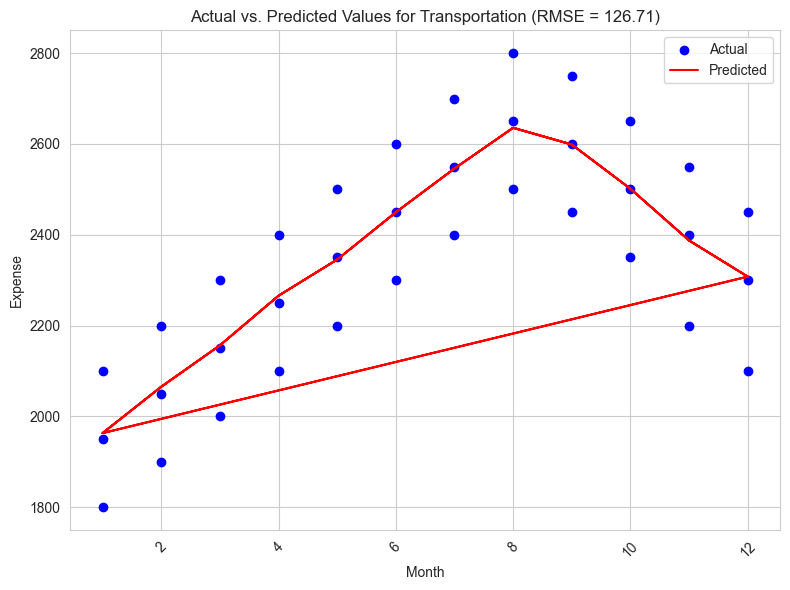

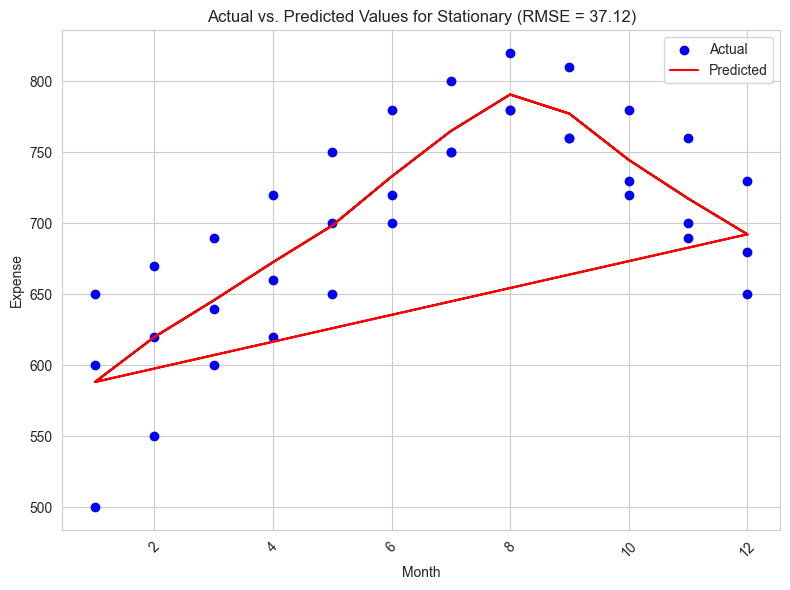

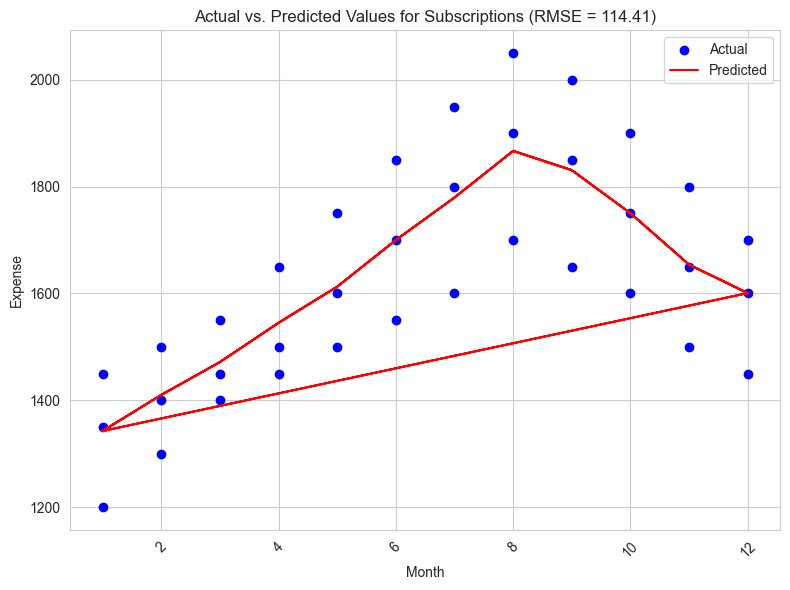

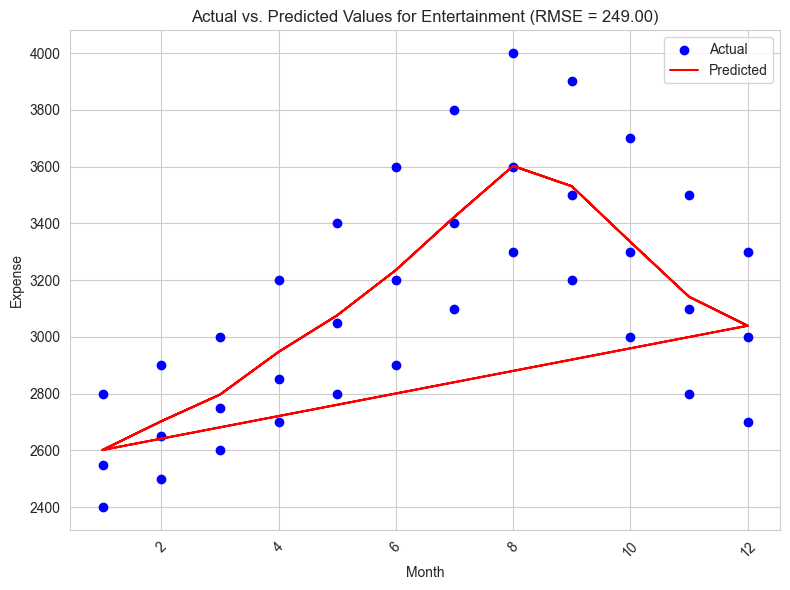

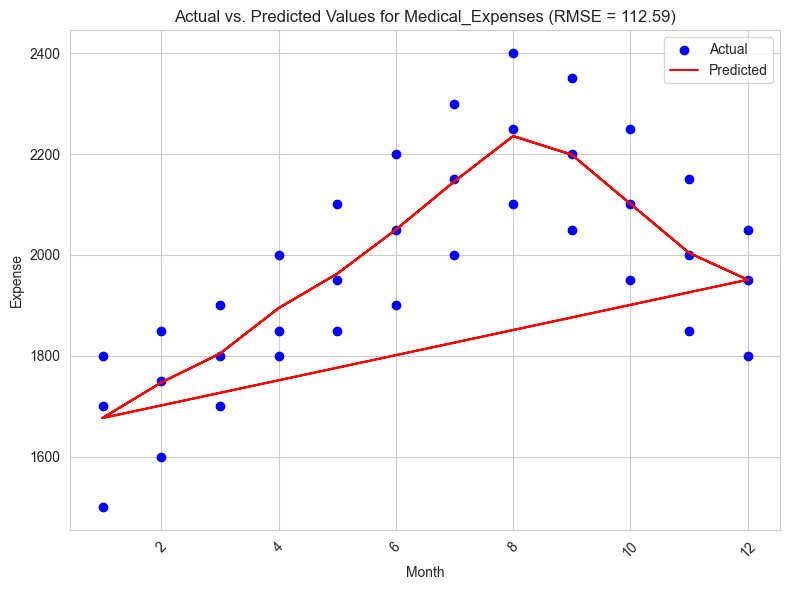

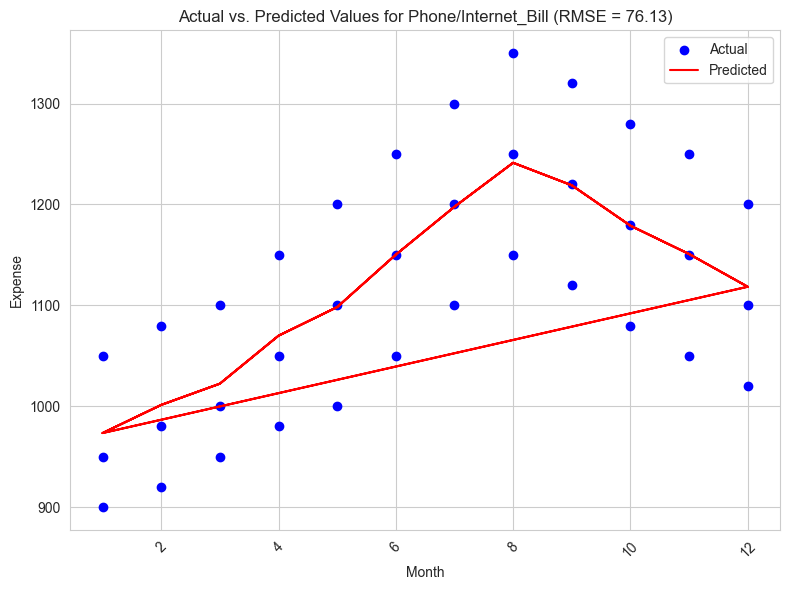

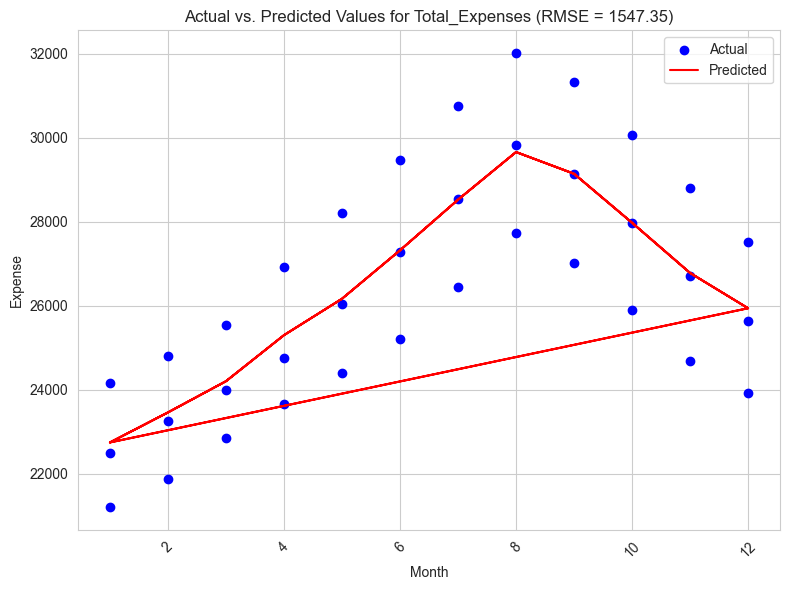

In [7]:
import matplotlib.pyplot as plt

# Function to visualize the actual vs. predicted values for each expense category
def visualize_predictions():
    for category, info in random_forest_models.items():
        model = info['model']
        rmse = info['rmse']
        
        # Predict expenses for all months
        predicted_expenses = model.predict(data['Month'].values.reshape(-1, 1))
        
        # Plot actual vs. predicted values
        plt.figure(figsize=(8, 6))
        plt.scatter(data['Month'], data[category], color='blue', label='Actual')
        plt.plot(data['Month'], predicted_expenses, color='red', label='Predicted')
        plt.title(f"Actual vs. Predicted Values for {category} (RMSE = {rmse:.2f})")
        plt.xlabel("Month")
        plt.ylabel("Expense")
        plt.legend()
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call the function to visualize predictions
visualize_predictions()
